# TP - Clasificación Multiclase de Texto con Regresión Softmax
### Redes Neuronales / Deep Learning

**Alumno**: Facundo Ortega

**Legajo**: 65560 


Dataset: **20 Newsgroups** (~18.000 posts de foros de Usenet, clasificados en 20 categorías).

## Objetivos
- Implementar un pipeline de preprocesamiento de texto **configurable** (stopwords, stemming, lematización, n-gramas).
- Implementar una **Regresión Softmax** (regresión logística multinomial) en PyTorch: una única capa lineal + `CrossEntropyLoss`, sin capas ocultas.
- Trackear el entrenamiento con **TensorBoard** y **MLflow**.
- Usar **Optuna** para buscar la mejor combinación de hiperparámetros de preprocesamiento *y* de entrenamiento en conjunto.

## Qué hay que completar
Los bloques marcados `# TODO` son los que tienen que completar ustedes. El resto ya está resuelto.

Esta notebook es individual/standalone: no tiene una sección de defensa grupal asociada.


### Frameworks y librerías utilizadas

| Framework | Qué es | Para qué se usa en esta notebook |
|---|---|---|
| **PyTorch** (`torch`, `torch.nn`, `torch.optim`, `torch.utils.data`) | Librería de deep learning: tensores (arrays que pueden vivir en GPU) + **autograd** (calcula gradientes automáticamente). | Definir el modelo (`nn.Linear`), la función de pérdida (`nn.CrossEntropyLoss`), el optimizador (`optim.Adam`, `optim.SGD`) y alimentar los datos en mini-batches (`TensorDataset` + `DataLoader`). |
| **scikit-learn** | Librería de machine learning "clásico". | Descargar el dataset (`fetch_20newsgroups`), vectorizar con TF-IDF (`TfidfVectorizer`), separar train/validación estratificado (`train_test_split`) y calcular métricas (`accuracy_score`, `classification_report`, `confusion_matrix`). |
| **NLTK** (Natural Language Toolkit) | Librería de procesamiento de lenguaje natural. | Tokenizar (`word_tokenize`), lista de stopwords en inglés, stemming (`PorterStemmer`) y lematización (`WordNetLemmatizer`). |
| **TensorBoard** | Dashboard web para visualizar métricas de entrenamiento (nació en TensorFlow, PyTorch lo soporta con `SummaryWriter`). | Curvas de loss y accuracy por época, para comparar runs visualmente dentro de Colab. |
| **MLflow** | Plataforma de *experiment tracking*: guarda, por cada run, sus **parámetros**, **métricas** y **artefactos** (ej. el modelo entrenado). | Registrar cada trial de Optuna, el entrenamiento final (con el modelo serializado) y los experimentos de dinámica, para poder consultarlos y compararlos después. |
| **Optuna** | Framework de optimización de hiperparámetros. | Buscar automáticamente la mejor combinación de preprocesamiento + entrenamiento usando el algoritmo **TPE** (búsqueda bayesiana). |
| **NumPy / pandas / Matplotlib** | Cálculo numérico, tablas y gráficos. | Análisis de resultados (tablas de trials, curvas, tiempos). |

**TensorBoard vs MLflow**: TensorBoard está pensado para *mirar curvas* (métricas vs época) de uno o varios runs. MLflow está pensado para *gestionar experimentos*: además de las métricas guarda los hiperparámetros de cada run, el modelo entrenado y permite buscar/filtrar runs desde código (`mlflow.search_runs`) o desde su UI.

## 0. Setup

In [4]:
!pip install -q mlflow optuna



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from torch.utils.tensorboard import SummaryWriter
import mlflow
import mlflow.pytorch
import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)


c:\Users\Facu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando dispositivo: cpu


**Explicación: imports, semillas y dispositivo**

- `re`, `random`: librerías estándar de Python (expresiones regulares y números aleatorios).
- `numpy`: arrays numéricos. `torch`, `torch.nn` (capas y funciones de pérdida), `torch.optim` (optimizadores), `DataLoader`/`TensorDataset` (armado de mini-batches).
- De `sklearn`: el dataset, el vectorizador TF-IDF, `train_test_split` y las métricas.
- De `nltk`: stopwords, stemmer, lematizador y tokenizador.
- `SummaryWriter` escribe los logs que lee TensorBoard; `mlflow` y `mlflow.pytorch` para tracking y para guardar el modelo; `optuna` para la búsqueda.

**Semillas (`SEED = 42`)**: se fija la semilla de los tres generadores aleatorios que intervienen: `random` (Python), `np.random` (NumPy, lo usa scikit-learn en algunos casos) y `torch.manual_seed` (inicialización de los pesos de `nn.Linear` y el orden aleatorio de los mini-batches con `shuffle=True`). Así los resultados son reproducibles entre ejecuciones.

**`device`**: si hay GPU (CUDA) disponible se usa, si no, CPU.

In [6]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Facu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Facu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Facu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Facu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Facu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**Explicación: recursos de NLTK**

NLTK no trae sus datos instalados; hay que descargarlos una vez:
- `stopwords`: listas de palabras vacías por idioma (usamos la de inglés, ~180 palabras).
- `wordnet` y `omw-1.4`: la base léxica WordNet (Open Multilingual Wordnet), que usa el lematizador para encontrar la forma de diccionario de cada palabra.
- `punkt` / `punkt_tab`: modelos del tokenizador que usa `word_tokenize` (versiones nuevas de NLTK usan `punkt_tab`).

## 1. Datos: 20 Newsgroups

Usamos `remove=('headers', 'footers', 'quotes')` para sacar metadata que haría el problema "demasiado fácil" (por ejemplo, el header a veces incluye el nombre del newsgroup).

In [7]:
newsgroups_train = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
newsgroups_test  = fetch_20newsgroups(subset="test",  remove=("headers", "footers", "quotes"))

class_names = newsgroups_train.target_names
NUM_CLASSES = len(class_names)
print(f"Clases ({NUM_CLASSES}):", class_names)
print(f"\nTrain: {len(newsgroups_train.data)} documentos | Test: {len(newsgroups_test.data)} documentos")

print("\n--- Ejemplo de documento ---")
print("Categoría:", class_names[newsgroups_train.target[0]])
print(newsgroups_train.data[0][:500])


Clases (20): ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Train: 11314 documentos | Test: 7532 documentos

--- Ejemplo de documento ---
Categoría: rec.autos
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


**Explicación: carga del dataset**

`fetch_20newsgroups` descarga el dataset y devuelve un objeto tipo diccionario con:
- `.data`: lista de strings, uno por documento (post).
- `.target`: array de enteros 0–19 con la clase de cada documento.
- `.target_names`: nombre de cada clase (índice → nombre).

`subset="train"` / `"test"` usa la partición **"bydate"** oficial: train son los posts más viejos y test los posteriores a cierta fecha. Es una partición **temporal**, más realista (y más difícil) que un split aleatorio, porque el modelo tiene que generalizar a temas/hilos posteriores.

`remove=("headers", "footers", "quotes")` elimina encabezados (que incluyen el newsgroup), firmas y citas de otros mensajes; sin esto el modelo "hace trampa" aprendiendo nombres de usuarios o del grupo.


## 2. Preprocesamiento configurable

Vamos a armar una función de preprocesamiento con estos hiperparámetros (todos van a formar parte de la búsqueda de Optuna más adelante):

- `remove_stopwords` (`True`/`False`): sacar palabras muy frecuentes y poco informativas (`the`, `is`, `and`, ...).
- `normalization` (`"none"` / `"stem"` / `"lemmatize"`):
  - `"none"`: no se normaliza la palabra.
  - `"stem"`: **stemming** con Porter Stemmer — corta la palabra a una raíz heurística (`"running"` → `"run"`, a veces resultados no son palabras reales: `"studies"` → `"studi"`).
  - `"lemmatize"`: **lematización** con WordNet — lleva la palabra a su forma de diccionario (`"running"` → `"run"`, `"studies"` → `"study"`), más lenta pero más "correcta" lingüísticamente.

### TODO 1: completar `preprocess_text`

Pasos esperados:
1. Tokenizar el texto con `word_tokenize`.
2. Pasar todo a minúsculas y quedarse solo con tokens alfabéticos (`token.isalpha()`), para descartar números y puntuación.
3. Si `remove_stopwords` es `True`, sacar los tokens que estén en el set de stopwords.
4. Según `normalization`, aplicar `stemmer.stem(token)`, `lemmatizer.lemmatize(token)`, o dejar el token igual.
5. Devolver los tokens unidos con espacios (un string, para poder pasárselo después a `TfidfVectorizer`).

In [8]:
STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()


def preprocess_text(text, remove_stopwords, normalization):
    tokens = word_tokenize(text.lower()) #Lo pasamos a minuscula
    tokens = [t for t in tokens if t.isalpha()]

    # TODO: si remove_stopwords es True, filtrar los tokens que están en STOP_WORDS
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]  #Lo que hacemos aca es que agrega a la lista tokes solo 
                                                             #aquellas palabras que no sean un STOP WORD

    # TODO: aplicar la normalización correspondiente según el valor de `normalization`
    if normalization == "stem":
        tokens = [STEMMER.stem(t) for t in tokens]  # Le aplicamos el STEMMER.stem a cada token
    elif normalization == "lemmatize":
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]  # Le aplicamos el LEMMATIZER.lemmatize a cada token
    # si normalization == "none", no se hace nada más

    return " ".join(tokens)


In [9]:
# Sanity check: probamos las distintas combinaciones sobre una oración de ejemplo
ejemplo = "The researchers were studying the running processes and stopping conditions of the engines."
for norm in ["none", "stem", "lemmatize"]:
    for rm_sw in [False, True]:
        resultado = preprocess_text(ejemplo, remove_stopwords=rm_sw, normalization=norm)
        print(f"normalization={norm:10s} remove_stopwords={str(rm_sw):5s} -> {resultado}")


normalization=none       remove_stopwords=False -> the researchers were studying the running processes and stopping conditions of the engines
normalization=none       remove_stopwords=True  -> researchers studying running processes stopping conditions engines
normalization=stem       remove_stopwords=False -> the research were studi the run process and stop condit of the engin
normalization=stem       remove_stopwords=True  -> research studi run process stop condit engin
normalization=lemmatize  remove_stopwords=False -> the researcher were studying the running process and stopping condition of the engine
normalization=lemmatize  remove_stopwords=True  -> researcher studying running process stopping condition engine


## 3. Vectorización TF-IDF

Convertimos los textos preprocesados en vectores numéricos con `TfidfVectorizer`. Como el preprocesamiento (tokenización, stopwords, normalización) ya lo hicimos nosotros, acá solo controlamos:

- `ngram_range`: `(1,1)` solo unigramas, o `(1,2)` unigramas + bigramas (captura algo de contexto, ej. `"new york"`).
- `max_features`: tamaño máximo del vocabulario (se queda con los términos más frecuentes).
- `min_df`: un término tiene que aparecer en al menos `min_df` documentos para entrar al vocabulario (filtra términos rarísimos / errores de tipeo).

### TODO 2: completar `vectorize_data`

In [10]:
def vectorize_data(train_texts, test_texts, ngram_range, max_features, min_df):

    # Creamos el vectorizador con los hiperparámetros recibidos
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=min_df
    )

    # Ajustamos y transformamos los datos de entrenamiento
    X_train = vectorizer.fit_transform(train_texts)

    # Transformamos los datos de test usando el mismo vectorizador
    X_test = vectorizer.transform(test_texts)
    
    return X_train, X_test, vectorizer


In [11]:
# Sanity check rápido con pocos documentos
_sample_train = ["the cat sat on the mat", "dogs are running in the park", "cats and dogs are pets"]
_sample_test = ["the dog sat on the mat"]
_Xtr, _Xte, _vec = vectorize_data(_sample_train, _sample_test, ngram_range=(1, 1), max_features=50, min_df=1)
assert _Xtr is not None, "Completá vectorize_data"
print("Shape train:", _Xtr.shape, "| Shape test:", _Xte.shape)
print("Vocabulario (parcial):", list(_vec.vocabulary_.keys())[:10])

#Imprimipos los resultados
print("\n=== TF-IDF ===")
features = _vec.get_feature_names_out()
matrix = np.round(_Xtr.toarray(), 2)

# Encabezado
print(f"{'Frase':<8}", end="")
for word in features:
    print(f"{word:>10}", end="")
print()

# Filas
for i, row in enumerate(matrix, start=1):
    print(f"{i:<8}", end="")
    for value in row:
        print(f"{value:>10.2f}", end="")
    print()


Shape train: (3, 13) | Shape test: (1, 13)
Vocabulario (parcial): ['the', 'cat', 'sat', 'on', 'mat', 'dogs', 'are', 'running', 'in', 'park']

=== TF-IDF ===
Frase          and       are       cat      cats      dogs        in       mat        on      park      pets   running       sat       the
1             0.00      0.00      0.40      0.00      0.00      0.00      0.40      0.40      0.00      0.00      0.00      0.40      0.61
2             0.00      0.35      0.00      0.00      0.35      0.46      0.00      0.00      0.46      0.00      0.46      0.00      0.35
3             0.49      0.37      0.00      0.49      0.37      0.00      0.00      0.00      0.00      0.49      0.00      0.00      0.00


**Explicación: `vectorize_data` y TF-IDF (TODO 2 resuelto)**

TF-IDF transforma cada documento en un vector de dimensión = tamaño del vocabulario. Para el término $t$ en el documento $d$:

$$\text{tfidf}(t,d) = \text{tf}(t,d)\cdot \text{idf}(t), \qquad \text{idf}(t) = \ln\frac{1+n}{1+\text{df}(t)} + 1$$

- $\text{tf}(t,d)$: cuántas veces aparece $t$ en $d$.
- $\text{df}(t)$: en cuántos documentos aparece $t$; $n$: cantidad de documentos. Palabras que aparecen en todos lados (ej. `"the"`) tienen idf bajo → pesan poco; palabras específicas (`"hockey"`, `"encryption"`) pesan mucho.
- Por defecto scikit-learn **normaliza cada fila con norma L2** (cada documento queda con $\|x\|_2 = 1$). Consecuencia importante para el entrenamiento: los valores de cada feature son **muy chicos** (típicamente 0.01–0.2) y la matriz es **muy dispersa** (cada documento usa unas pocas decenas/centenas de términos de miles posibles). Esto hace que los gradientes por peso sean chicos y explica por qué se necesitan learning rates relativamente altos (lo vemos en los análisis).

Hiperparámetros: `ngram_range` (unigramas o unigramas+bigramas), `max_features` (se queda con los términos de mayor frecuencia total), `min_df` (descarta términos que aparecen en menos de `min_df` documentos).

**Por qué `fit` sólo en train**: `fit_transform(train)` aprende el vocabulario y los idf con train; `transform(test)` usa esos mismos valores. Si se hiciera `fit` con test también, información del test se "filtraría" al modelo (*data leakage*) y la evaluación sería optimista.

## 4. Modelo: Regresión Softmax

La regresión softmax (regresión logística multinomial) es el modelo más simple posible para clasificación multiclase: **una sola capa lineal** que mapea el vector de entrada a un score (logit) por clase, sin ninguna no-linealidad ni capa oculta.

`CrossEntropyLoss` de PyTorch ya incluye internamente un `log_softmax` + `NLLLoss`, así que el modelo **no debe aplicar softmax en el forward** — hay que devolver los logits crudos.

### TODO 3: completar `SoftmaxRegression`

In [12]:
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # Única capa lineal: z = W x + b, con W de shape (num_classes, input_dim) y b de shape (num_classes,)
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # Devolvemos los logits crudos. NO aplicamos softmax: CrossEntropyLoss ya lo hace internamente
        return self.linear(x)


In [13]:
# Sanity check
_dummy = torch.randn(4, 50)
_model_check = SoftmaxRegression(input_dim=50, num_classes=20)
_out = _model_check(_dummy)
assert _out is not None and _out.shape == (4, 20), "Revisá SoftmaxRegression"
print("Shape de salida OK:", _out.shape)


Shape de salida OK: torch.Size([4, 20])


**Explicación: `SoftmaxRegression` (TODO 3 resuelto)**

El modelo es una sola capa lineal `nn.Linear(input_dim, num_classes)`:

$$z = Wx + b,\qquad W\in\mathbb{R}^{20\times d},\ b\in\mathbb{R}^{20}$$

Cada fila $w_k$ de $W$ es un "detector" de la clase $k$: el logit $z_k = w_k\cdot x + b_k$ es alto si el documento contiene términos con peso positivo para esa clase. Cantidad de parámetros: $20\cdot d + 20$ (con $d=10000$ son 200.020 parámetros).

La probabilidad de cada clase es el softmax de los logits y la pérdida es la entropía cruzada:

$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}, \qquad \mathcal{L} = -\log p_y$$

`nn.CrossEntropyLoss` recibe **los logits crudos** y calcula internamente `log_softmax` + `NLLLoss` de forma numéricamente estable (truco *log-sum-exp*). Si aplicáramos softmax en el `forward`, se aplicaría **dos veces**: las probabilidades quedarían "aplastadas" hacia valores parecidos, los gradientes serían más chicos y el entrenamiento más lento/peor. Para predecir usamos `argmax` de los logits, que da la misma clase que el argmax de las probabilidades (softmax es monótona).

El *sanity check* verifica que para un batch de 4 vectores de dimensión 50 la salida tiene shape `(4, 20)`: un logit por clase.

## 5. Entrenamiento (ya resuelto)

Dado que los datos vectorizados entran en memoria sin problema, armamos `DataLoader`s a partir de tensores densos. Logueamos loss y accuracy (train y validación) por época a TensorBoard, y a MLflow además los hiperparámetros y el modelo final.

In [14]:
%load_ext tensorboard


In [15]:
def to_tensor_dataset(X, y):
    X_dense = torch.tensor(X.toarray(), dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_dense, y_tensor)


def train_softmax_model(model, train_loader, val_loader, optimizer, epochs, writer=None, run_name="softmax"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_loss += loss.item() * xb.size(0)
                correct += (logits.argmax(dim=1) == yb).sum().item()
                total += xb.size(0)
        val_loss, val_acc = running_loss / total, correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{run_name}] Epoch {epoch+1}/{epochs} - "
              f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

        if writer is not None:
            writer.add_scalars("loss", {"train": train_loss, "val": val_loss}, epoch)
            writer.add_scalars("accuracy", {"train": train_acc, "val": val_acc}, epoch)
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("train_acc", train_acc, step=epoch)
        mlflow.log_metric("val_acc", val_acc, step=epoch)

    return history


## 6. Búsqueda de hiperparámetros con Optuna

La búsqueda incluye **hiperparámetros de preprocesamiento** (`remove_stopwords`, `normalization`, `ngram_range`, `max_features`, `min_df`) y **de entrenamiento** (`lr`, `batch_size`), todos en un mismo `objective`.

**Optimización de tiempo**: como la tokenización + stopwords + normalización es lo más lento del pipeline (y solo depende de `remove_stopwords` y `normalization`, que tienen pocas combinaciones posibles), la precalculamos una sola vez para las 6 combinaciones posibles y la cacheamos. Así, cada trial de Optuna solo repite la parte rápida (vectorizar + entrenar pocas épocas).

**Explicación de la sección 6: qué hace el código**

**Celda de precálculo (`preprocessed_cache`)**
- Recorre las 6 combinaciones posibles de `remove_stopwords` (True/False) × `normalization` ("none", "stem", "lemmatize").
- Para cada una aplica `preprocess_text` a los 11.314 documentos de train y a los 7.532 de test, y guarda el resultado en un diccionario con clave `(remove_stopwords, normalization)`.
- Motivo: tokenizar y normalizar ~18.800 documentos es lo más lento del pipeline, y sólo depende de esos dos hiperparámetros. Se calcula una vez y cada trial lo busca en el diccionario, en vez de recalcularlo 15 veces.

**Función `objective(trial)`**: Optuna la llama una vez por trial (15 veces). En cada llamada:
1. **Elige hiperparámetros** con `trial.suggest_*`:
   - `suggest_categorical` elige entre una lista de opciones (stopwords, normalización, n-gramas, `max_features`, `min_df`, `batch_size`).
   - `suggest_float("lr", 1e-3, 1e-1, log=True)` elige un learning rate en **escala logarítmica**: es igual de probable caer entre 0.001 y 0.01 que entre 0.01 y 0.1. Es lo adecuado para un lr, porque lo que importa es su orden de magnitud.
2. **Toma los textos ya preprocesados** de la caché.
3. **Separa validación**: `train_test_split(..., test_size=0.2, stratify=...)` deja 80% del train para entrenar (9.051 docs) y 20% para validar (2.263 docs). `stratify` mantiene la proporción de cada clase en ambas partes y `random_state=SEED` hace que el split sea siempre el mismo, así los trials son comparables. **El test no se usa**: si eligiéramos hiperparámetros mirando el test, su accuracy dejaría de ser una estimación honesta.
4. **Vectoriza con TF-IDF** (ajustando el vocabulario sólo con la parte de train) y arma los `DataLoader`.
5. **Crea un modelo nuevo**, entrena **5 épocas** con Adam y **devuelve la `val_acc` de la última época**. Ese número es lo que Optuna intenta maximizar.

**`optuna.create_study(direction="maximize")` + `study.optimize(objective, n_trials=15)`**: crea la búsqueda y ejecuta los 15 trials. El sampler por defecto es **TPE** (*Tree-structured Parzen Estimator*):
- Los **primeros 10 trials son aleatorios** (fase de exploración).
- A partir del trial 10, TPE separa los trials ya hechos en "buenos" y "malos", modela qué valores de hiperparámetros aparecen en cada grupo y propone valores parecidos a los buenos. Con 15 trials, sólo los últimos 5 están "guiados".

Al final, `study.best_params` y `study.best_value` tienen la mejor configuración y su val_acc.

In [16]:
print("Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...")
preprocessed_cache = {}
for remove_stopwords in [False, True]:
    for normalization in ["none", "stem", "lemmatize"]:
        key = (remove_stopwords, normalization)
        train_proc = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_train.data]
        test_proc  = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_test.data]
        preprocessed_cache[key] = (train_proc, test_proc)
        print("  listo:", key)


Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...
  listo: (False, 'none')
  listo: (False, 'stem')
  listo: (False, 'lemmatize')
  listo: (True, 'none')
  listo: (True, 'stem')
  listo: (True, 'lemmatize')


In [17]:
def objective(trial):
    remove_stopwords = trial.suggest_categorical("remove_stopwords", [False, True])
    normalization = trial.suggest_categorical("normalization", ["none", "stem", "lemmatize"])
    ngram_range = trial.suggest_categorical("ngram_range", ["1gram", "1_2gram"])
    ngram_range_tuple = (1, 1) if ngram_range == "1gram" else (1, 2)
    max_features = trial.suggest_categorical("max_features", [2000, 5000, 10000])
    min_df = trial.suggest_categorical("min_df", [1, 2, 5])
    lr = trial.suggest_float("lr", 1e-3, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_texts, test_texts = preprocessed_cache[(remove_stopwords, normalization)]
    # Partimos una porción de train como validación para la búsqueda (no usamos el test acá)
    tr_texts, val_texts, tr_labels, val_labels = train_test_split(
        train_texts, newsgroups_train.target, test_size=0.2, random_state=SEED,
        stratify=newsgroups_train.target,
    )

    X_tr, X_val, _ = vectorize_data(tr_texts, val_texts, ngram_range_tuple, max_features, min_df)
    train_loader = DataLoader(to_tensor_dataset(X_tr, tr_labels), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(to_tensor_dataset(X_val, val_labels), batch_size=batch_size, shuffle=False)

    model = SoftmaxRegression(input_dim=X_tr.shape[1], num_classes=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = train_softmax_model(model, train_loader, val_loader, optimizer, epochs=5, run_name=f"trial_{trial.number}")

    return history["val_acc"][-1]


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor accuracy de validación:", study.best_value)


[I 2026-09-30 02:58:21,760] A new study created in memory with name: no-name-de6d3711-e87e-4f2f-91f5-8cdae8d15bbd


[trial_0] Epoch 1/5 - train_loss: 2.5062 train_acc: 0.5120 - val_loss: 2.0986 val_acc: 0.6262
[trial_0] Epoch 2/5 - train_loss: 1.7253 train_acc: 0.7437 - val_loss: 1.6872 val_acc: 0.6452
[trial_0] Epoch 3/5 - train_loss: 1.3340 train_acc: 0.7848 - val_loss: 1.4798 val_acc: 0.6536
[trial_0] Epoch 4/5 - train_loss: 1.1033 train_acc: 0.8107 - val_loss: 1.3640 val_acc: 0.6513


[I 2026-09-30 02:58:31,210] Trial 0 finished with value: 0.6579761378700839 and parameters: {'remove_stopwords': True, 'normalization': 'stem', 'ngram_range': '1_2gram', 'max_features': 2000, 'min_df': 1, 'lr': 0.00819732059120092, 'batch_size': 64}. Best is trial 0 with value: 0.6579761378700839.


[trial_0] Epoch 5/5 - train_loss: 0.9514 train_acc: 0.8304 - val_loss: 1.2937 val_acc: 0.6580
[trial_1] Epoch 1/5 - train_loss: 1.8678 train_acc: 0.5468 - val_loss: 1.3377 val_acc: 0.6452
[trial_1] Epoch 2/5 - train_loss: 0.8860 train_acc: 0.7946 - val_loss: 1.1912 val_acc: 0.6553
[trial_1] Epoch 3/5 - train_loss: 0.6446 train_acc: 0.8547 - val_loss: 1.1672 val_acc: 0.6518
[trial_1] Epoch 4/5 - train_loss: 0.5102 train_acc: 0.8949 - val_loss: 1.1776 val_acc: 0.6465


[I 2026-09-30 02:58:34,893] Trial 1 finished with value: 0.6416261599646487 and parameters: {'remove_stopwords': True, 'normalization': 'stem', 'ngram_range': '1_2gram', 'max_features': 2000, 'min_df': 2, 'lr': 0.045804350224485924, 'batch_size': 128}. Best is trial 0 with value: 0.6579761378700839.


...

[trial_12] Epoch 5/5 - train_loss: 0.3937 train_acc: 0.9555 - val_loss: 1.0542 val_acc: 0.7172
[trial_13] Epoch 1/5 - train_loss: 1.8980 train_acc: 0.5676 - val_loss: 1.3489 val_acc: 0.6761
[trial_13] Epoch 2/5 - train_loss: 0.8108 train_acc: 0.8533 - val_loss: 1.1491 val_acc: 0.6942
[trial_13] Epoch 3/5 - train_loss: 0.5241 train_acc: 0.9103 - val_loss: 1.0971 val_acc: 0.6840
[trial_13] Epoch 4/5 - train_loss: 0.3780 train_acc: 0.9407 - val_loss: 1.0821 val_acc: 0.6774


[I 2026-09-30 02:59:12,795] Trial 13 finished with value: 0.6743261157755193 and parameters: {'remove_stopwords': False, 'normalization': 'none', 'ngram_range': '1gram', 'max_features': 5000, 'min_df': 1, 'lr': 0.020049887167226766, 'batch_size': 32}. Best is trial 7 with value: 0.7193990278391516.


[trial_13] Epoch 5/5 - train_loss: 0.2919 train_acc: 0.9562 - val_loss: 1.0825 val_acc: 0.6743
[trial_14] Epoch 1/5 - train_loss: 2.5911 train_acc: 0.4950 - val_loss: 2.2076 val_acc: 0.6655
[trial_14] Epoch 2/5 - train_loss: 1.7472 train_acc: 0.8335 - val_loss: 1.7579 val_acc: 0.7022
[trial_14] Epoch 3/5 - train_loss: 1.2675 train_acc: 0.8850 - val_loss: 1.5104 val_acc: 0.7128
[trial_14] Epoch 4/5 - train_loss: 0.9787 train_acc: 0.9083 - val_loss: 1.3631 val_acc: 0.7154


[I 2026-09-30 02:59:16,127] Trial 14 finished with value: 0.7220503756076005 and parameters: {'remove_stopwords': False, 'normalization': 'none', 'ngram_range': '1gram', 'max_features': 10000, 'min_df': 5, 'lr': 0.010113824270359928, 'batch_size': 128}. Best is trial 14 with value: 0.7220503756076005.


[trial_14] Epoch 5/5 - train_loss: 0.7910 train_acc: 0.9234 - val_loss: 1.2681 val_acc: 0.7221
Mejores hiperparámetros: {'remove_stopwords': False, 'normalization': 'none', 'ngram_range': '1gram', 'max_features': 10000, 'min_df': 5, 'lr': 0.010113824270359928, 'batch_size': 128}
Mejor accuracy de validación: 0.7220503756076005


**Análisis de los resultados de la búsqueda**

Los 15 trials, ordenados por val_acc. "Mejor época" es la época de mayor val_acc dentro de las 5.

| # | val_acc | stopwords | normalización | n-gramas | max_features | min_df | lr | batch | mejor época |
|---|---|---|---|---|---|---|---|---|---|
| **5** | **0.7371** | quitar | stem | 1gram | 10000 | 5 | 0.0032 | 32 | 5 |
| 13 | 0.7362 | quitar | stem | 1gram | 10000 | 5 | 0.0140 | 32 | 3 |
| 11 | 0.7313 | quitar | lemmatize | 1gram | 10000 | 5 | 0.0041 | 32 | 5 |
| 14 | 0.7309 | quitar | stem | 1-2gram | 10000 | 5 | 0.0097 | 32 | 4 |
| 12 | 0.7296 | quitar | stem | 1gram | 10000 | 1 | 0.0029 | 32 | 5 |
| 10 | 0.7234 | quitar | lemmatize | 1gram | 10000 | 5 | 0.0024 | 32 | 5 |
| 0 | 0.7203 | dejar | none | 1gram | 10000 | 2 | 0.0074 | 32 | 5 |
| 8 | 0.7203 | dejar | none | 1gram | 10000 | 1 | 0.0137 | 64 | 4 |
| 6 | 0.6916 | quitar | none | 1-2gram | 5000 | 2 | 0.0058 | 32 | 4 |
| 7 | 0.6752 | quitar | lemmatize | 1-2gram | 5000 | 5 | 0.0528 | 128 | 2 |
| 9 | 0.6593 | quitar | none | 1-2gram | 5000 | 5 | 0.0471 | 64 | 2 |
| 3 | 0.6500 | dejar | stem | 1-2gram | 5000 | 5 | 0.0040 | 32 | 4 |
| 4 | 0.6394 | quitar | stem | 1gram | 2000 | 1 | 0.0277 | 32 | 2 |
| 1 | 0.6076 | dejar | stem | 1-2gram | 2000 | 5 | 0.0201 | 128 | 5 |
| 2 | 0.6010 | dejar | lemmatize | 1-2gram | 2000 | 1 | 0.0109 | 32 | 4 |

**1. `max_features` es el factor que más pesa.** Los 8 mejores trials usan 10.000 features, y la tabla queda prácticamente ordenada por este hiperparámetro:

| max_features | trials | val_acc promedio |
|---|---|---|
| 2.000 | 3 | ≈ 0.616 |
| 5.000 | 4 | ≈ 0.669 |
| 10.000 | 8 | ≈ 0.729 |

Con más vocabulario el modelo tiene más términos específicos de cada tema (nombres de equipos, de programas, de lugares). Para una regresión softmax el costo extra es bajo: 20 × 10.000 = 200.000 pesos.

**2. Quitar stopwords ayuda un poco, sobre todo con límite de vocabulario.** Entre los trials con 10.000 features, los 6 que quitan stopwords promedian ≈0.731 y los 2 que las dejan, 0.720 (≈1 punto). Las stopwords casi no aportan información temática, y con un tope de `max_features`, sacarlas libera lugares del vocabulario para palabras de contenido.

**3. Los bigramas no aportan nada.** Los trials con `1_2gram` y 2.000–5.000 features están todos en la mitad inferior (0.60–0.69). Si no se sacan las stopwords, los bigramas más frecuentes son del tipo "of the", "in the" o "i have": ocupan el vocabulario y desplazan unigramas útiles. El único trial con bigramas que anda bien (#14, 0.731) es justamente el que quita stopwords y usa 10.000 features, y aun así no supera a los unigramas.

**4. Stem vs lemmatize: empate.** El mejor con stem da 0.737 y el mejor con lemmatize 0.731, una diferencia dentro del ruido (ver punto 7).

**5. El learning rate controla la dinámica dentro de las 5 épocas:**
- **lr alto** (≈0.05, trials 7 y 9): la val_acc llega a su máximo en la **época 2** y después baja, la val_loss empieza a subir y la train_acc llega a ~0.96. El modelo **sobreajusta** muy rápido.
- **lr bajo** (≈0.002–0.004, trials 5, 10, 11 y 12): la val_acc y la val_loss **siguen mejorando en la época 5**. Todavía no convergieron, pero en esta corrida quedaron arriba.
- **lr intermedio** (≈0.01, trials 13 y 14): alcanzan casi el mismo valor antes (mejor época 3–4).

Como el objetivo es la accuracy de **la época 5**, el resultado depende de cuántas épocas se entrena. Con otra cantidad de épocas, el lr óptimo sería distinto.

**6. Comportamiento de TPE.** El mejor trial (#5) salió en la **fase aleatoria**. Los trials guiados (10 a 14) se concentraron alrededor de él: todos quitan stopwords, usan 10.000 features, batch 32 y lr entre 0.002 y 0.014, y dieron 0.723–0.736. TPE no encontró algo mejor, pero confirmó que esa región es buena.

**7. Cuidado con sobreinterpretar el ganador.** Con 2.263 documentos de validación, el error estándar de una accuracy de ~0.73 es $\sqrt{0.73\cdot0.27/2263}\approx0.009$ (≈1 punto). Los 5 mejores trials (0.730–0.737) están **empatados estadísticamente**. Lo robusto no es "stem con lr=0.0032", sino **unigramas, 10.000 features, sin stopwords y un lr moderado**.

## 7. Entrenamiento final

Usamos los mejores hiperparámetros encontrados por Optuna, entrenamos con **todo** el train set y por más épocas, evaluando contra el test set real (que no se usó en la búsqueda).

In [18]:
import os

for p in ["runs", os.path.join("runs", "softmax_final")]:
    if os.path.isfile(p):                      # existe pero es un ARCHIVO, no una carpeta
        nuevo = p + "_archivo_viejo"
        os.rename(p, nuevo)
        print(f"'{p}' era un archivo -> renombrado a '{nuevo}'")

os.makedirs(os.path.join("runs", "softmax_final"), exist_ok=True)   # crea las carpetas si no existen
print("Carpeta de trabajo:", os.getcwd())
print("runs es carpeta:", os.path.isdir("runs"))

Carpeta de trabajo: c:\Users\Facu\Desktop\1er Cuatri 4to (Bioingenieria)\Redes Neuronales\Tps Redes Neuronales
runs es carpeta: True


In [19]:
from torch.utils.tensorboard import SummaryWriter
import os
w = SummaryWriter(r"C:\tb_logs\test")
w.add_scalar("prueba", 1.0, 0); w.close()
print(os.listdir(r"C:\tb_logs\test"))   # debería mostrar un events.out.tfevents...

['events.out.tfevents.1790656640.DESKTOP-0FBTNN3.26016.0', 'events.out.tfevents.1790659072.DESKTOP-0FBTNN3.16008.0', 'events.out.tfevents.1790747736.DESKTOP-0FBTNN3.28880.0', 'events.out.tfevents.1790747956.DESKTOP-0FBTNN3.28880.1']


In [20]:
best = study.best_params
BEST_REMOVE_SW = best["remove_stopwords"]
BEST_NORM = best["normalization"]
BEST_NGRAM = (1, 1) if best["ngram_range"] == "1gram" else (1, 2)
BEST_MAX_FEATURES = best["max_features"]
BEST_MIN_DF = best["min_df"]
BEST_LR = best["lr"]
BEST_BATCH_SIZE = best["batch_size"]
EPOCHS_FINAL = 20

train_texts_final, test_texts_final = preprocessed_cache[(BEST_REMOVE_SW, BEST_NORM)]
X_train_final, X_test_final, vectorizer_final = vectorize_data(
    train_texts_final, test_texts_final, BEST_NGRAM, BEST_MAX_FEATURES, BEST_MIN_DF
)

train_loader_final = DataLoader(to_tensor_dataset(X_train_final, newsgroups_train.target),
                                 batch_size=BEST_BATCH_SIZE, shuffle=True)
test_loader_final = DataLoader(to_tensor_dataset(X_test_final, newsgroups_test.target),
                                batch_size=BEST_BATCH_SIZE, shuffle=False)

model = SoftmaxRegression(input_dim=X_train_final.shape[1], num_classes=NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
writer = SummaryWriter(log_dir="runs/softmax_final")

# [CAMBIO] Cerramos el run que quedó abierto "implícitamente" durante la búsqueda de Optuna.
# Si no hay ninguno activo, end_run() no hace nada, así que es seguro llamarlo siempre.
mlflow.end_run()

mlflow.set_experiment("softmax_20newsgroups")
with mlflow.start_run(run_name="softmax_final"):
    mlflow.log_params({
        "remove_stopwords": BEST_REMOVE_SW, "normalization": BEST_NORM,
        "ngram_range": str(BEST_NGRAM), "max_features": BEST_MAX_FEATURES, "min_df": BEST_MIN_DF,
        "lr": BEST_LR, "batch_size": BEST_BATCH_SIZE, "epochs": EPOCHS_FINAL,
    })
    history = train_softmax_model(model, train_loader_final, test_loader_final, optimizer,
                                   epochs=EPOCHS_FINAL, writer=writer, run_name="final")

    # [CAMBIO] MLflow 3.x exige un input_example para guardar el modelo PyTorch.
    # Le pasamos 5 documentos de test ya vectorizados (array float32 de shape (5, n_features)).
    # MLflow además lo usa para registrar la "firma" del modelo (tipo y forma de entrada/salida).
    input_example = X_test_final[:5].toarray().astype(np.float32)
    mlflow.pytorch.log_model(model.cpu(), "model", input_example=input_example)

writer.close()


[final] Epoch 1/20 - train_loss: 2.5018 train_acc: 0.5333 - val_loss: 2.1556 val_acc: 0.6263
[final] Epoch 2/20 - train_loss: 1.6038 train_acc: 0.8270 - val_loss: 1.7505 val_acc: 0.6518
[final] Epoch 3/20 - train_loss: 1.1484 train_acc: 0.8730 - val_loss: 1.5444 val_acc: 0.6596
[final] Epoch 4/20 - train_loss: 0.8868 train_acc: 0.8991 - val_loss: 1.4288 val_acc: 0.6622
[final] Epoch 5/20 - train_loss: 0.7206 train_acc: 0.9178 - val_loss: 1.3596 val_acc: 0.6637
[final] Epoch 6/20 - train_loss: 0.6055 train_acc: 0.9295 - val_loss: 1.3125 val_acc: 0.6634
[final] Epoch 7/20 - train_loss: 0.5209 train_acc: 0.9390 - val_loss: 1.2819 val_acc: 0.6620
[final] Epoch 8/20 - train_loss: 0.4560 train_acc: 0.9457 - val_loss: 1.2591 val_acc: 0.6599
[final] Epoch 9/20 - train_loss: 0.4050 train_acc: 0.9515 - val_loss: 1.2438 val_acc: 0.6595
[final] Epoch 10/20 - train_loss: 0.3639 train_acc: 0.9559 - val_loss: 1.2332 val_acc: 0.6576
[final] Epoch 11/20 - train_loss: 0.3303 train_acc: 0.9593 - val_loss

2026/09/30 02:59:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[final] Epoch 20/20 - train_loss: 0.1829 train_acc: 0.9698 - val_loss: 1.2225 val_acc: 0.6456


**Explicación de la sección 7: qué hace el código**

1. **Lee los mejores hiperparámetros** de `study.best_params`. Como `ngram_range` se guardó como texto ("1gram" / "1_2gram"), se convierte a la tupla que espera `TfidfVectorizer`: `(1, 1)` o `(1, 2)`.
2. **Vectoriza con todo el train** (11.314 docs, ya no el 80%) y transforma el test (7.532 docs). El vocabulario y los idf se aprenden sólo con train.
3. **Arma los `DataLoader`**: el de train con `shuffle=True` (orden aleatorio en cada época) y el de test con `shuffle=False`.
4. **Crea un modelo nuevo** y un optimizador Adam con el mejor lr, y entrena **20 épocas** (en la búsqueda eran 5).
5. **TensorBoard**: `SummaryWriter("runs/softmax_final")` guarda las curvas de loss y accuracy por época.
6. **MLflow**:
   - `mlflow.end_run()` cierra el run implícito que quedó abierto de la búsqueda.
   - `set_experiment` + `start_run` crean el run `softmax_final`.
   - `log_params` guarda los hiperparámetros, y `train_softmax_model` registra las métricas de cada época.
   - `mlflow.pytorch.log_model(..., input_example=...)` guarda el modelo entrenado. Se puede recargar después con `mlflow.pytorch.load_model`. El `input_example` (5 documentos vectorizados) lo exige MLflow 3.x y sirve para registrar la "firma" del modelo: forma y tipo de la entrada.
7. `writer.close()` asegura que TensorBoard escriba todo a disco.

**Aclaración**: en esta celda el `val_loader` es el **test set**. Por eso lo que el log llama "val" son en realidad métricas de **test**. Está bien para *monitorear*, pero no hay que usar estas curvas para decidir cuántas épocas entrenar. Eso sería ajustar un hiperparámetro mirando el test.

**Análisis del entrenamiento final**

Épocas seleccionadas del log (lr = 0.0032, batch = 32):

| época | train_loss | train_acc | test_loss | test_acc |
|---|---|---|---|---|
| 1 | 2.595 | 0.588 | 2.308 | 0.648 |
| 3 | 1.414 | 0.857 | 1.665 | 0.677 |
| 5 | 0.938 | 0.896 | 1.414 | 0.680 |
| **7** | 0.695 | 0.916 | 1.293 | **0.6815** ← máximo de test_acc |
| 10 | 0.493 | 0.936 | 1.205 | 0.679 |
| 15 | 0.319 | 0.956 | 1.153 | 0.675 |
| 18 | 0.259 | 0.962 | **1.1476** ← mínimo de test_loss | 0.670 |
| 20 | 0.229 | 0.964 | 1.150 | **0.6682** |

**1. La accuracy de test se estanca temprano y después baja apenas.** Sube rápido hasta la época 5–7 (≈0.68) y luego desciende de a poco hasta 0.668. Mientras tanto la train_acc sigue subiendo hasta 0.964. La **brecha train–test** pasa de ~0.2 a ~0.30. Es **sobreajuste**: después de la época ~7, el modelo sigue mejorando en train memorizando detalles propios de esos documentos, que no generalizan.

**2. Loss y accuracy no tocan su óptimo en la misma época.** La test_loss sigue bajando hasta la época 18, pero la test_acc ya había llegado a su máximo en la 7. La loss mide qué tan confiado está el modelo, y la accuracy sólo si el argmax es correcto:
- En las épocas 7–18 el modelo gana confianza en documentos que ya clasificaba bien (baja la loss).
- Al mismo tiempo cambia de opinión en algunos casos dudosos, y empeora un poco la accuracy.

En la época 19–20 la test_loss empieza a subir: el modelo se vuelve demasiado confiado en sus errores.

**3. ¿Por qué 0.668 en test si la búsqueda dio 0.737 en validación?** Son 7 puntos de diferencia, con tres causas:
- **Split temporal**: el test de 20 Newsgroups ("bydate") tiene posts **posteriores** a los de train, con hilos y temas nuevos. La validación, en cambio, se sacó al azar **del propio train**: son posts de la misma época y muchas veces de los mismos hilos que los de entrenamiento, así que es más "fácil" y la estimación resulta optimista.
- **Sesgo de selección** (*winner's curse*): elegimos el mejor de 15 trials por su val_acc. Parte de esa ventaja es suerte del split y no se repite en datos nuevos.
- **5 vs 20 épocas**: el lr se eligió para rendir bien en 5 épocas; con 20, el modelo pasa su punto óptimo y sobreajusta.



In [21]:
%tensorboard --logdir runs


Reusing TensorBoard on port 6006 (pid 23292), started 1 day, 1:17:38 ago. (Use '!kill 23292' to kill it.)

![TensorBoard - entrenamiento final](Imagen_TensorBoard.png)

## 8. Evaluación final

In [22]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader_final:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy en test: {test_accuracy:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


Accuracy en test: 0.6456

                          precision    recall  f1-score   support

             alt.atheism       0.47      0.44      0.45       319
           comp.graphics       0.57      0.60      0.59       389
 comp.os.ms-windows.misc       0.57      0.57      0.57       394
comp.sys.ibm.pc.hardware       0.59      0.58      0.58       392
   comp.sys.mac.hardware       0.64      0.59      0.62       385
          comp.windows.x       0.74      0.64      0.69       395
            misc.forsale       0.75      0.78      0.77       390
               rec.autos       0.68      0.67      0.67       396
         rec.motorcycles       0.70      0.69      0.69       398
      rec.sport.baseball       0.52      0.81      0.63       397
        rec.sport.hockey       0.87      0.83      0.85       399
               sci.crypt       0.78      0.67      0.72       396
         sci.electronics       0.58      0.56      0.57       393
                 sci.med       0.76      0.72    

**Explicación de la sección 8: evaluación**

**Celda de predicción y reporte**
- `model.eval()` + `torch.no_grad()`: modo evaluación, sin calcular gradientes.
- Para cada batch de test se calculan los logits y la clase predicha con `argmax` (la clase de mayor logit es la de mayor probabilidad, porque la softmax es monótona).
- Se juntan todas las predicciones y etiquetas reales en `all_preds` y `all_labels`.

**Métricas de `classification_report`**, para cada clase $k$:
- **precision**: de los documentos que el modelo predijo como $k$, qué fracción era realmente $k$. Una precision baja significa que la clase "atrae" documentos ajenos (falsos positivos).
- **recall**: de los documentos que realmente eran $k$, qué fracción encontró. Un recall bajo significa que los documentos de esa clase se "escapan" a otras (falsos negativos).
- **f1-score**: media armónica de precision y recall, $2PR/(P+R)$.
- **support**: cantidad de documentos reales de la clase en test.
- **macro avg**: promedio simple entre clases (todas pesan igual). **weighted avg**: promedio ponderado por support.

**Matriz de confusión**: la fila $i$, columna $j$ cuenta cuántos documentos de la clase real $i$ se predijeron como $j$. La diagonal son los aciertos y todo lo que está fuera de la diagonal son errores. Cuanto más oscuro, más documentos.

**Análisis de la evaluación**

**Resultado global: accuracy 0.668, macro-F1 0.66.** Como referencia, el azar daría 1/20 = 0.05. Para un modelo lineal sobre bolsa de palabras en 20 Newsgroups **sin headers/footers/quotes**, es un valor esperable: sin quitar esa metadata se superaría fácilmente 0.85, porque el modelo aprendería nombres de usuarios y del grupo.

**Clases mejor clasificadas** (F1 ≥ 0.75): `rec.sport.hockey` (0.88), `talk.politics.mideast` (0.77), `misc.forsale`, `sci.crypt` y `sci.med` (0.75). Todas tienen vocabulario muy propio: "puck", "nhl", "israel", "arab", "sale", "shipping", "encryption", "key", "doctor", "patients".

**Clases peor clasificadas**:

| clase | precision | recall | F1 | interpretación |
|---|---|---|---|---|
| `talk.religion.misc` | 0.35 | 0.33 | 0.34 | 2 de cada 3 documentos se van a otras clases |
| `alt.atheism` | 0.50 | 0.48 | 0.49 | se mezcla con las otras dos de religión |
| `talk.politics.misc` | 0.54 | 0.45 | 0.49 | se confunde con `talk.politics.guns` |
| `sci.electronics` | 0.60 | 0.56 | 0.58 | se reparte entre las de hardware de computadoras |

**Un caso llamativo: `rec.sport.baseball`** tiene recall alto (0.84) pero precision baja (0.55). El modelo predice "baseball" para unos 600 documentos, de los cuales sólo ~333 lo son: recibe **~270 falsos positivos**. En la matriz se ve como una **columna clara pero visible en casi todas las filas**, y es raro, porque no hay razón temática para que, por ejemplo, un post de `sci.space` hable de béisbol.

La hipótesis más probable son los **documentos vacíos**. Al quitar headers, footers y citas, y después stopwords con `min_df=5`, algunos documentos quedan **sin ningún término del vocabulario**: su vector TF-IDF es todo ceros. Para un vector nulo, los logits son sólo los sesgos ($z = W\cdot 0 + b = b$), así que el modelo les asigna **siempre la misma clase**: la de mayor sesgo.

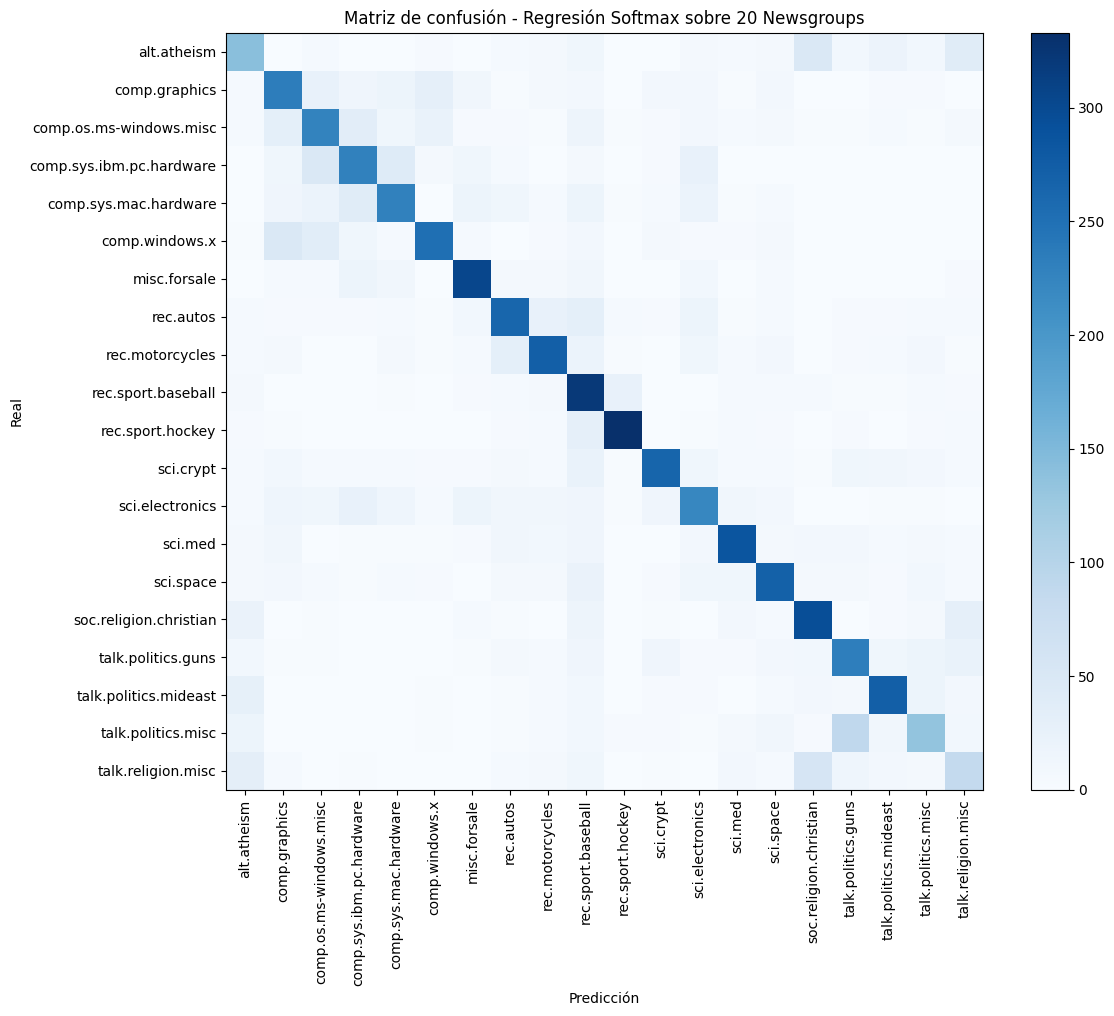

In [23]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=90)
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Regresión Softmax sobre 20 Newsgroups")
plt.tight_layout()
plt.show()


**Qué muestra la matriz de confusión**

Fuera de la diagonal, los errores **no están repartidos al azar**: se agrupan en **bloques de temas parecidos**.
- **Religión**: `talk.religion.misc` → `soc.religion.christian` y `alt.atheism`. `alt.atheism` → `soc.religion.christian` y `talk.religion.misc`. Son las celdas más oscuras fuera de la diagonal.
- **Política**: `talk.politics.misc` → `talk.politics.guns` (una de las confusiones más grandes). También `talk.politics.misc` ↔ `talk.religion.misc`.
- **Computación**: `comp.windows.x` → `comp.graphics` y `comp.os.ms-windows.misc`. `comp.sys.ibm.pc.hardware` ↔ `comp.sys.mac.hardware` ↔ `comp.os.ms-windows.misc`, y todas con `sci.electronics`.
- **Vehículos**: `rec.autos` ↔ `rec.motorcycles`.
- **Columna de `rec.sport.baseball`**: el efecto de los documentos vacíos explicado arriba.

La celda de "top confusiones" lista los números exactos. El porqué de estos bloques está en la respuesta a la pregunta 9.

## 9. Preguntas de reflexión

**Sobre Regresión Softmax (teoría)**
1. ¿Por qué la regresión softmax es una generalización de la regresión logística binaria? ¿Qué pasaría si `NUM_CLASSES = 2`?
2. ¿Por qué `CrossEntropyLoss` en PyTorch no necesita que se le aplique `softmax` antes en el forward? ¿Qué pasaría si igual lo aplicaran (softmax + CrossEntropyLoss)?
3. ¿Qué tipo de frontera de decisión puede aprender un modelo de regresión softmax? ¿Qué limitación tiene frente a un problema que no es linealmente separable?
4. ¿En qué se diferencia este modelo de una red neuronal con capas ocultas? ¿En qué situación elegirían una sobre la otra?

**Sobre frameworks y herramientas**
5. ¿Qué ventajas y desventajas tiene implementar esto en PyTorch (como hicimos) comparado con usar directamente `sklearn.linear_model.LogisticRegression(multi_class="multinomial")`?
6. ¿Para qué sirvió específicamente MLflow en este TP? ¿En qué se diferencia de lo que loguea TensorBoard?
7. ¿Qué ventaja concreta les dio Optuna frente a probar combinaciones de hiperparámetros a mano?

**Sobre el experimento**
8. ¿Qué combinación de preprocesamiento (stopwords, stemming/lematización, n-gramas) encontró Optuna como mejor? ¿Tiene sentido para este dataset?
9. ¿En qué categorías del dataset se confunde más el modelo (según la matriz de confusión)? ¿Por qué creen que pasa (piensen en el contenido temático de esas categorías)?
10. ¿Cambiaría su respuesta a la pregunta anterior si usaran un modelo con capas ocultas en vez de regresión softmax? ¿Por qué sí o por qué no?


## Respuestas a las preguntas de reflexión

### Sobre Regresión Softmax (teoría)

**1. ¿Por qué la regresión softmax es una generalización de la regresión logística binaria? ¿Qué pasaría si `NUM_CLASSES = 2`?**

La regresión logística modela una sola probabilidad, $P(y=1\mid x)=\sigma(w^\top x+b)$, con la sigmoidea $\sigma(h)=1/(1+e^{-h})$. La softmax tiene un vector de pesos por clase y normaliza los $K$ puntajes: $P(y=k\mid x)=e^{h_k}/\sum_j e^{h_j}$ con $h_k=w_k^\top x+b_k$.

Con $K=2$, dividiendo numerador y denominador por $e^{h_1}$:

$$P(y=1\mid x)=\frac{e^{h_1}}{e^{h_0}+e^{h_1}}=\frac{1}{1+e^{-(h_1-h_0)}}=\sigma\big((w_1-w_0)^\top x+(b_1-b_0)\big)$$

Es **exactamente una regresión logística** con pesos $w=w_1-w_0$ y sesgo $b=b_1-b_0$. Además, la `CrossEntropyLoss` con 2 clases coincide con la entropía cruzada binaria.

Si pusiéramos `NUM_CLASSES = 2`, el modelo funcionaría y sería equivalente a una regresión logística, pero **sobreparametrizado**: tendría dos vectores de pesos cuando sólo importa su diferencia. Sumar el mismo vector a $w_0$ y $w_1$ no cambia ninguna probabilidad. Lo habitual en binario es usar una sola salida (`nn.Linear(d, 1)`) con `BCEWithLogitsLoss`.

**2. ¿Por qué `CrossEntropyLoss` no necesita que se aplique `softmax` en el forward? ¿Qué pasaría si igual lo aplicaran?**

Porque `CrossEntropyLoss` **ya incluye la softmax**: internamente calcula `log_softmax` + `NLLLoss`, es decir $\text{loss}=-z_y+\log\sum_j e^{z_j}$. Por eso **espera logits crudos**. Hacerlo todo junto tiene dos ventajas:
- Es **numéricamente estable** (truco *log-sum-exp*, restando el máximo), mientras que calcular primero la softmax y después su log puede dar `log(0) = -inf`.
- El gradiente queda muy simple: $\partial\text{loss}/\partial z_k=\hat p_k-y_k$.

Si aplicaran softmax en el forward **y además** `CrossEntropyLoss`, la softmax se aplicaría **dos veces**:
- Las entradas de la segunda softmax serían probabilidades en $[0,1]$, así que las diferencias entre "logits" nunca superarían 1 y la salida quedaría **aplastada cerca de la uniforme**.
- Aun con una predicción perfecta, $p=(1,0,\dots,0)$, la pérdida no podría bajar de $-\log\frac{e}{e+19}\approx 2.08$ (con 20 clases), contra ~0 en el modelo correcto.
- Los gradientes serían mucho más chicos, así que entrenaría mucho más lento y peor.

La accuracy podría no ser catastrófica, porque la softmax es monótona y no cambia el argmax, pero el entrenamiento se degrada.

**3. ¿Qué tipo de frontera de decisión puede aprender? ¿Qué limitación tiene ante un problema no linealmente separable?**

**Fronteras lineales.** Entre dos clases $k$ y $l$, la frontera es donde empatan, $h_k=h_l$, o sea $(w_k-w_l)^\top x+(b_k-b_l)=0$: un **hiperplano**. La región de cada clase es la intersección de los semiespacios donde gana a todas las demás, así que el espacio queda dividido en **regiones convexas** limitadas por hiperplanos.

**Limitación**: no puede separar clases cuya frontera real es curva o cuyas regiones no son convexas.

En texto esto se traduce en que **no puede modelar interacciones entre palabras**. El puntaje de cada clase es una suma de contribuciones independientes de cada término, así que no puede aprender reglas como "'bank' indica economía, salvo que aparezca junto a 'river'". Algunas interacciones sólo se capturan si se agregan como features explícitos (por ejemplo, bigramas).

En la práctica, con 10.000 dimensiones y ~11.000 documentos, los datos de train son casi linealmente separables (train_acc 0.96). En texto la limitación lineal pesa menos que en problemas de pocas dimensiones.

**4. ¿En qué se diferencia de una red con capas ocultas? ¿Cuándo elegirían una u otra?**

Una red con capas ocultas aplica transformaciones lineales seguidas de **activaciones no lineales** (ReLU, tanh...) antes de la capa de salida softmax. Eso le permite:
- **aprender su propia representación** de los datos, con combinaciones de features en la capa oculta;
- trazar **fronteras no lineales**: con suficientes neuronas puede aproximar cualquier frontera.

La regresión softmax es un caso particular: una red **sin capas ocultas**. Diferencias prácticas:

| | Regresión softmax | Red con capas ocultas |
|---|---|---|
| Frontera | Lineal | No lineal |
| Función de costo | **Convexa**: un único óptimo, entrenamiento predecible | No convexa: depende de la inicialización |
| Parámetros | Pocos (20 × 10.000) | Muchos más, con más riesgo de sobreajuste |
| Interpretabilidad | Alta: cada peso $w_{k,j}$ dice cuánto empuja la palabra $j$ hacia la clase $k$ | Baja |
| Costo y ajuste | Rápida, pocos hiperparámetros | Más lenta, más hiperparámetros (capas, neuronas, dropout...) |

**Elegiría softmax** como *baseline* siempre, y como modelo final con features de alta dimensión y dispersos (como TF-IDF, donde lo lineal ya funciona bien), con pocos datos o cuando se necesita interpretar el modelo. **Elegiría una red con capas ocultas** cuando hay muchos datos, cuando las interacciones entre features importan, o con entradas densas (embeddings, imágenes, señales), donde la representación aprendida marca la diferencia.

### Sobre frameworks y herramientas

**5. ¿Ventajas y desventajas de PyTorch frente a `LogisticRegression(multi_class="multinomial")`?**

**Ventajas de PyTorch**:
- **Control total** del loop de entrenamiento: podemos loguear cada época en TensorBoard y MLflow, cambiar la loss, agregar early stopping o schedulers.
- **Mini-batches y GPU**: escala a datasets que no entran en memoria.
- **Se extiende trivialmente**: pasar a una red con capas ocultas es agregar dos líneas al `nn.Module`.
- Es el mismo framework que se usa para deep learning, así que lo aprendido se reutiliza.

**Desventajas**:
- **Más código y más lugares para equivocarse** (olvidar `zero_grad`, aplicar softmax dos veces...).
- Hay que **elegir a mano lr, épocas y batch size**, y no hay garantía de llegar al óptimo. `LogisticRegression` usa solvers como L-BFGS que resuelven el problema convexo hasta converger, trae **regularización L2 incluida** (parámetro `C`) y en una línea da el óptimo.
- **Memoria**: acá convertimos la matriz TF-IDF dispersa a densa (`X.toarray()`: 11.314 × 10.000 × 4 bytes ≈ 450 MB), mientras que sklearn trabaja directamente con matrices dispersas.


**6. ¿Para qué sirvió MLflow? ¿En qué se diferencia de lo que loguea TensorBoard?**

MLflow es una herramienta de **gestión de experimentos**. En el run `softmax_final` guardó:
- los **hiperparámetros** usados (`log_params`);
- las **métricas por época** (`log_metric`);
- el **modelo entrenado** como artefacto (`log_model`), que se puede volver a cargar con `mlflow.pytorch.load_model` sin reentrenar, y queda asociado a los hiperparámetros y métricas que lo produjeron.

Todo queda en `mlruns/` y se puede consultar y filtrar desde código (`mlflow.search_runs`) o desde la interfaz (`mlflow ui`). Eso permite comparar runs y reproducir resultados.

TensorBoard, en cambio, está pensado para **visualizar curvas de entrenamiento** (métricas vs época) en tiempo real y comparar corridas gráficamente. No guarda el modelo ni organiza los hiperparámetros de cada corrida de forma consultable. En resumen, TensorBoard sirve para *mirar cómo entrena* y MLflow para *registrar qué se hizo y con qué resultado*.

**7. ¿Qué ventaja concreta les dio Optuna frente a probar combinaciones a mano?**

- **Cubrir un espacio grande con pocos intentos.** Sólo los hiperparámetros categóricos dan 2 × 3 × 2 × 3 × 3 × 3 = 324 combinaciones. Con 5 valores de lr serían 1.620, y a ~4 s cada una, casi 2 horas de grid search. Optuna hizo 15 trials en **≈1 minuto** y encontró una región buena.
- **Búsqueda guiada (TPE)**: después de 10 trials aleatorios, concentró los siguientes en la zona prometedora. Los trials 10–14 quitan stopwords, usan 10.000 features, batch 32 y lr moderado, y todos dieron entre 0.723 y 0.736.
- **Muestreo logarítmico del lr** (`log=True`), difícil de hacer bien a mano.
- **Registro automático** de todos los trials (`study.trials_dataframe()`) para analizarlos después, como en la tabla de la sección 6.
- **Menos sesgo humano**: probando a mano uno tiende a explorar sólo lo que "cree" que va a funcionar.

Limitación: con 15 trials la búsqueda es casi aleatoria, y sin semilla en el sampler no es reproducible.

### Sobre el experimento

**8. ¿Qué combinación de preprocesamiento encontró Optuna como mejor? ¿Tiene sentido?**

El mejor trial (#5, val_acc 0.737) usó **quitar stopwords + stemming + unigramas**, con `max_features=10000` y `min_df=5` (y lr = 0.0032, batch 32).

Sí tiene sentido para este dataset:
- **Quitar stopwords**: clasificar newsgroups es un problema **temático**. Palabras como "the", "is" o "and" aparecen en todos los grupos y no discriminan. Con un tope de 10.000 términos, sacarlas deja lugar a palabras de contenido.
- **Stemming**: une variantes de una misma raíz ("encrypt", "encrypted", "encryption" → "encrypt"; "plays", "played", "playing" → "play"). Con ~11.000 documentos eso **junta evidencia dispersa**: el modelo aprende un solo peso para la raíz en vez de varios pesos con pocos ejemplos cada uno. Que la raíz no sea una palabra real ("studi") no importa, porque el modelo sólo necesita consistencia.
- **Unigramas**: el tema se reconoce por palabras clave individuales ("hockey", "god", "windows"). Con el tope de features, los bigramas compiten por el vocabulario con esos unigramas informativos.
- **`min_df=5`**: descarta términos que aparecen en menos de 5 documentos (errores de tipeo, palabras muy raras), que sólo servirían para memorizar.

Matiz importante: los mejores trials están estadísticamente empatados (0.730–0.737, ±0.9 puntos). Lemmatize dio 0.731 y bigramas sin stopwords 0.731. Lo que la búsqueda muestra con claridad es la importancia de **10.000 features** y de **no combinar bigramas con stopwords**. Stem vs lemmatize es un empate.

**9. ¿En qué categorías se confunde más el modelo? ¿Por qué?**

Según la matriz y el reporte, los errores se concentran en **grupos temáticamente vecinos**:
- **Religión**: `talk.religion.misc` (recall 0.33, F1 0.34, la peor clase) se va sobre todo a `soc.religion.christian` y `alt.atheism`. `alt.atheism` (F1 0.49) se confunde con las otras dos. Los tres grupos discuten los mismos temas con el mismo vocabulario ("god", "jesus", "bible", "faith", "belief", "church"), y la diferencia está en la **postura** (creyente, ateo, debate general), no en las palabras. Una bolsa de palabras no capta postura: "god does not exist" y "god exists" comparten casi todos los términos.
- **Política**: `talk.politics.misc` (F1 0.49) se confunde sobre todo con `talk.politics.guns`. Comparten "government", "law", "rights", "state" o "clinton", y buena parte del debate político general de la época trataba sobre armas.
- **Computación**: las cinco `comp.*` más `sci.electronics` se confunden entre sí ("windows.x" → "graphics", "ibm.pc" ↔ "mac", hardware ↔ electrónica). Comparten jerga técnica ("card", "drive", "monitor", "driver", "software", "chip").
- **Vehículos**: `rec.autos` ↔ `rec.motorcycles` ("engine", "ride", "dealer", "speed").

**Por qué pasa**:
- **Solapamiento real de vocabulario**: el modelo lineal decide sumando pesos de palabras, y estas clases usan casi las mismas palabras.
- **Las clases "misc" son cajones de sastre**: `talk.religion.misc` y `talk.politics.misc` agrupan lo que no encaja en los grupos específicos, así que su contenido es por definición una mezcla de los temas vecinos. Además tienen menos documentos (support 251 y 310), así que el modelo tiene menos ejemplos para aprenderlas.
- **Cross-posting y ambigüedad**: en Usenet muchos posts se publicaban en varios grupos a la vez o tocaban temas de ambos, así que algunos "errores" son casos genuinamente ambiguos.

**10. ¿Cambiaría la respuesta anterior con un modelo con capas ocultas?**

**En parte sí, pero no en lo esencial.**

**Lo que podría mejorar**: una red con capas ocultas sobre el mismo TF-IDF puede aprender **combinaciones de palabras**. Por ejemplo, que "god" junto con "atheist", "evidence" y "exist" indica `alt.atheism`, mientras que "god" con "prayer" y "church" indica `soc.religion.christian`. También puede trazar fronteras no lineales entre clases vecinas. Eso podría reducir algo las confusiones dentro de los bloques (religión, computación) y ganar algunos puntos de accuracy.

**Lo que no cambiaría**:
- **Los pares más confundidos seguirían siendo los mismos**, porque la causa principal está en los **datos**: vocabulario compartido, categorías "misc" que son una mezcla de las demás, y posts genuinamente ambiguos o publicados en varios grupos. Ningún modelo puede separar lo que la etiqueta misma no separa con claridad.
- **La representación sigue siendo bolsa de palabras**: el orden y la negación siguen perdidos. Para captar *postura* ("does not exist") hace falta una representación que conserve el contexto (embeddings + redes recurrentes o transformers), no sólo más capas.
- **Los documentos vacíos seguirían mal clasificados**: sin información de entrada, cualquier modelo sólo puede adivinar.
- **Con ~11.000 documentos y 10.000 features**, una red más grande tiene más riesgo de **sobreajuste**. La regresión softmax ya llega a train_acc 0.96 con test 0.67, así que una red con capas ocultas necesitaría regularización fuerte (dropout, weight decay, early stopping) para mejorar en test.

En resumen, la matriz de confusión con capas ocultas se vería un poco más "limpia" en la diagonal, pero **con los mismos bloques** de confusión.